Images saved as 'structural_metrics.png' and 'structural_metrics.pdf'.


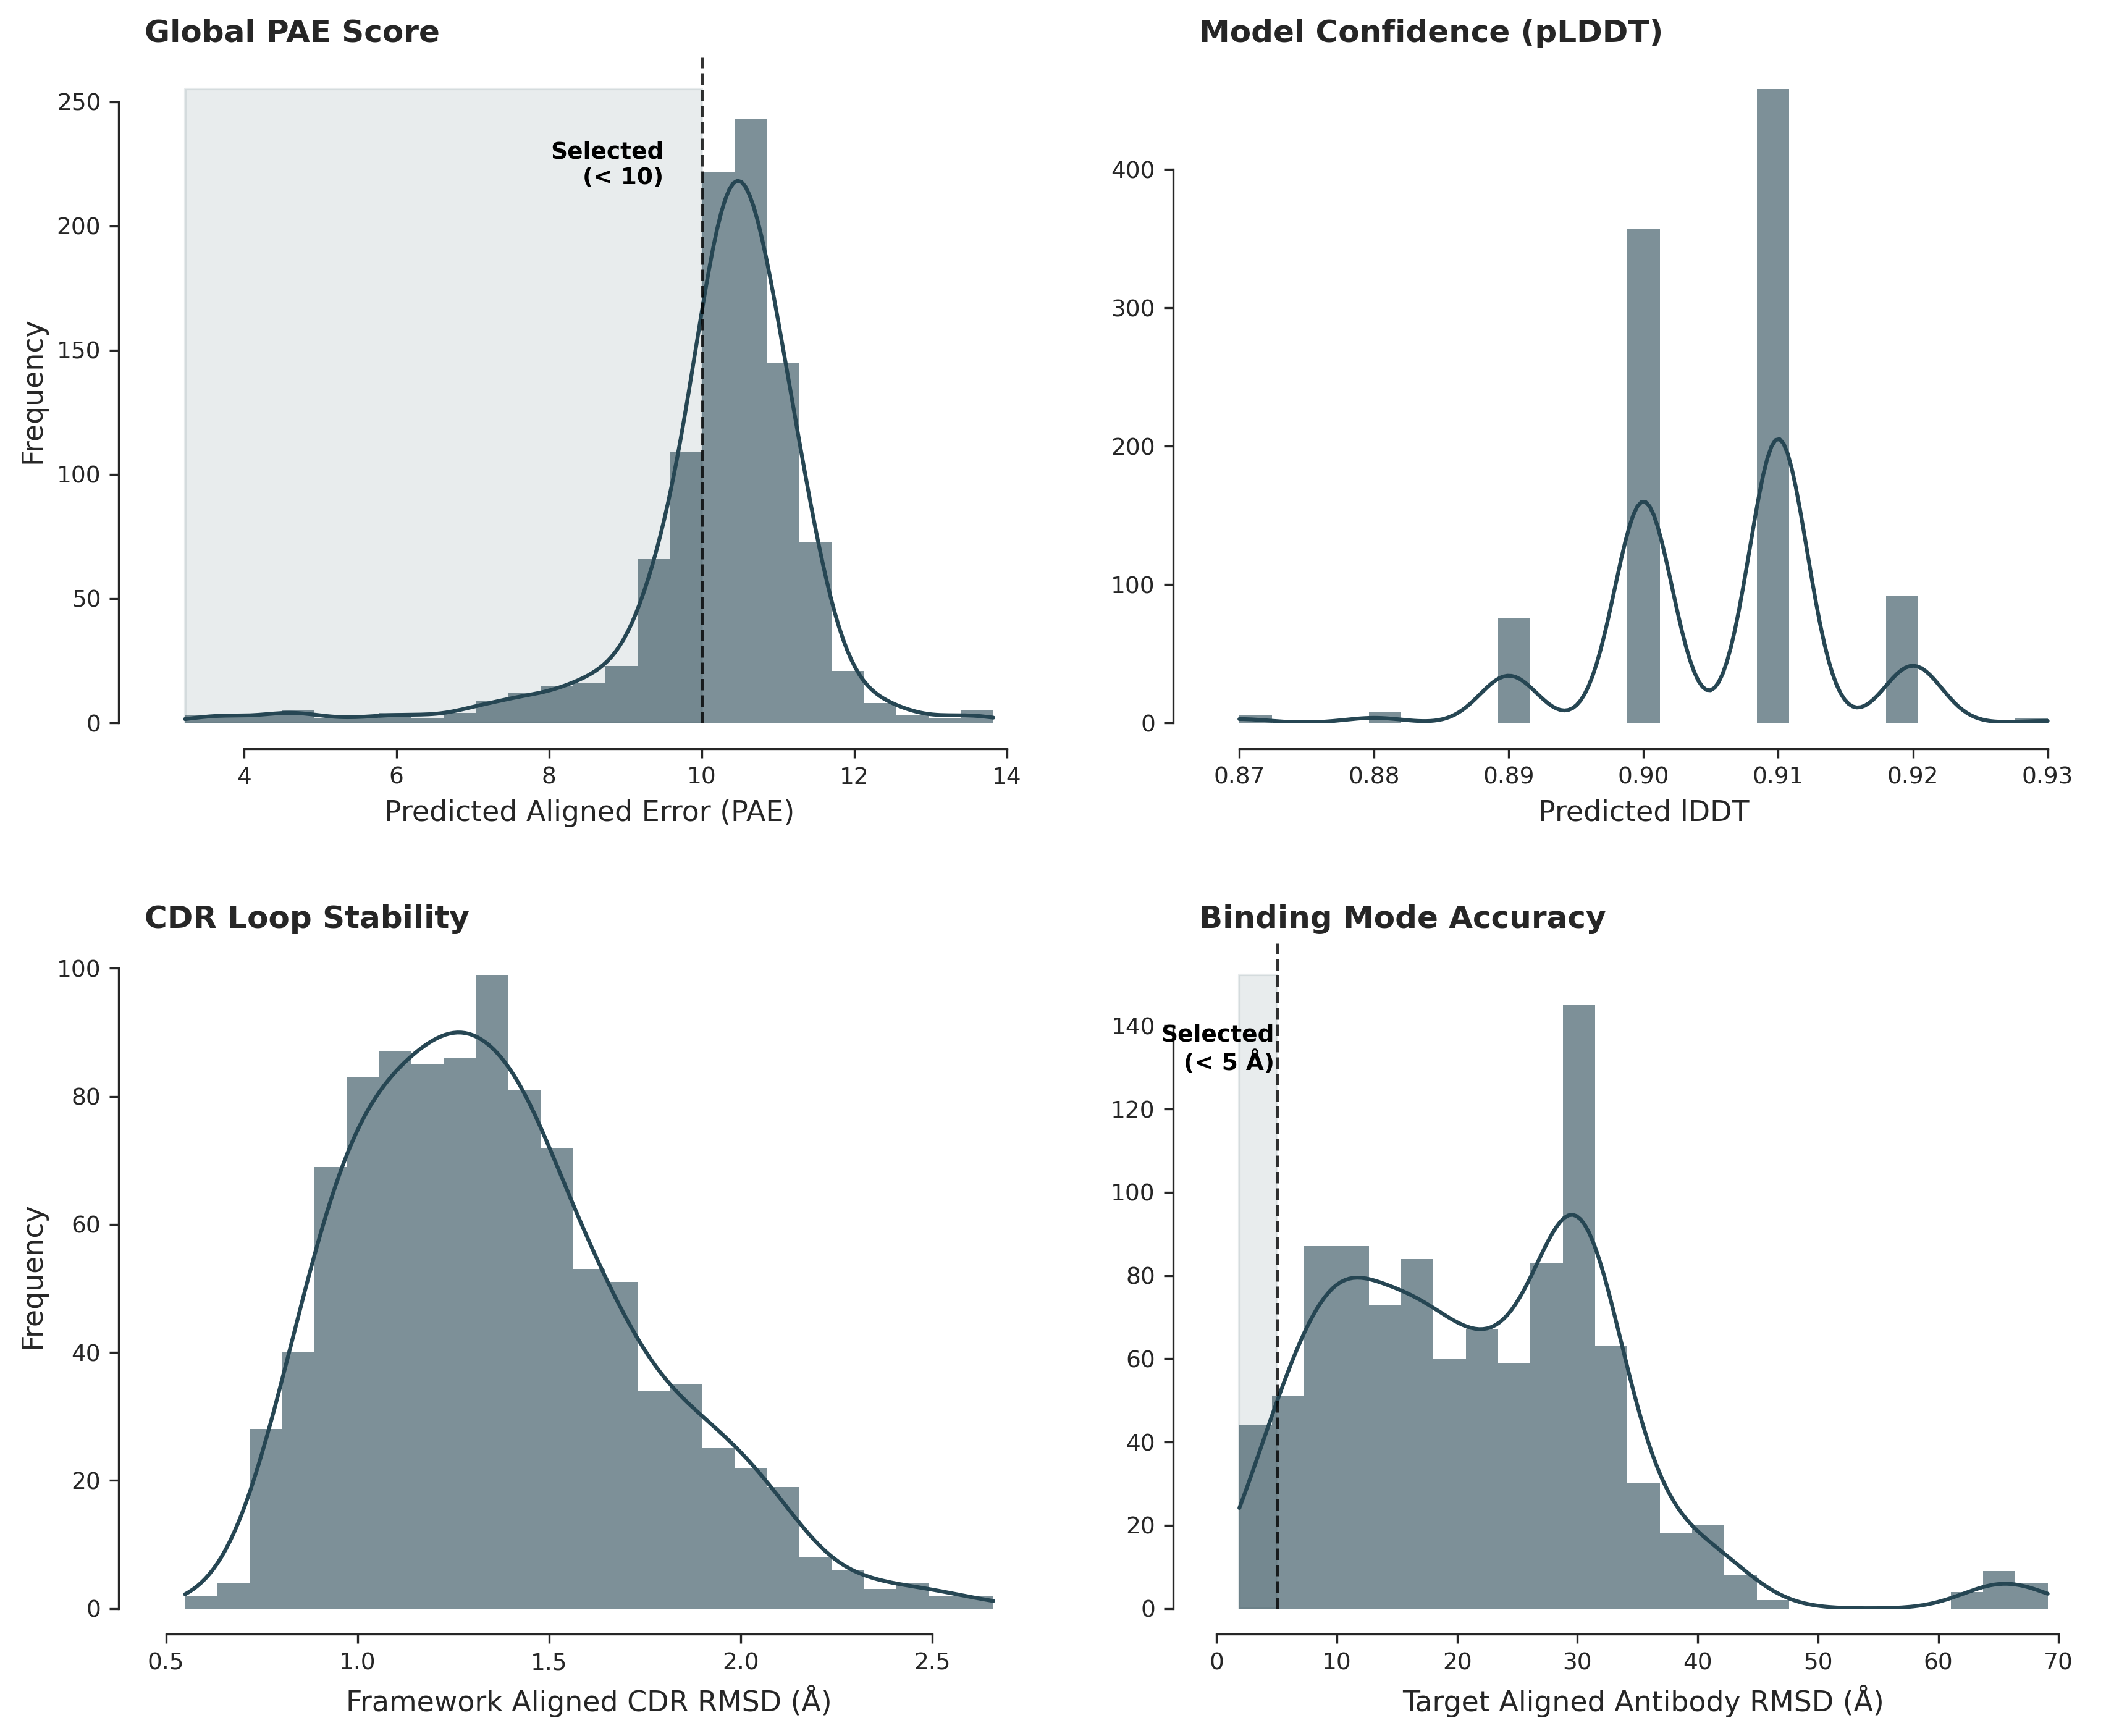

In [ ]:
# RFantibody structural metrics
#for potential 1000 scfv candidate
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. STYLE SETTINGS (Nature/Science Standard) ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['figure.titlesize'] = 14

# "Ticks" style: Remove grids, push axis lines outward
sns.set_style("ticks")

# Data Check
if 'df_all' not in locals():
    input_file = '/content/3_rf2.sc'
    try:
        df_all = pd.read_csv(input_file, sep=r'\s+')
    except:
        print("Data could not be loaded, please check the df_all variable.")
        df_all = pd.DataFrame()

if not df_all.empty:
    # --- UNIFORM COLOR SELECTION ---
    UNIFORM_COLOR = "#264653"

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)

    # --- PLOT 1: PAE (Cutoff < 10) ---
    ax1 = axes[0, 0]
    sns.histplot(df_all['pae'], bins=25, kde=True, ax=ax1,
                 color=UNIFORM_COLOR, alpha=0.6, element="step", linewidth=0)

    cutoff_pae = 10
    ax1.axvline(x=cutoff_pae, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ymin, ymax = ax1.get_ylim()
    ax1.fill_betweenx([ymin, ymax], df_all['pae'].min(), cutoff_pae, color=UNIFORM_COLOR, alpha=0.1)
    ax1.text(cutoff_pae - 0.5, ymax*0.85, 'Selected\n(< 10)',
             horizontalalignment='right', color='black', fontsize=9, fontweight='bold')
    ax1.set_xlabel('Predicted Aligned Error (PAE)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Global PAE Score', loc='left', fontweight='bold')

    # --- PLOT 2: Predicted lDDT ---
    ax2 = axes[0, 1]
    sns.histplot(df_all['pred_lddt'], bins=25, kde=True, ax=ax2,
                 color=UNIFORM_COLOR, alpha=0.6, element="step", linewidth=0)
    ax2.set_xlabel('Predicted lDDT')
    ax2.set_ylabel('')
    ax2.set_title('Model Confidence (pLDDT)', loc='left', fontweight='bold')

    # --- PLOT 3: Framework Aligned CDR RMSD ---
    ax3 = axes[1, 0]
    sns.histplot(df_all['framework_aligned_cdr_rmsd'], bins=25, kde=True, ax=ax3,
                 color=UNIFORM_COLOR, alpha=0.6, element="step", linewidth=0)
    ax3.set_xlabel('Framework Aligned CDR RMSD (Å)')
    ax3.set_ylabel('Frequency')
    ax3.set_title('CDR Loop Stability', loc='left', fontweight='bold')

    # --- PLOT 4: Target Aligned Antibody RMSD (Cutoff < 5) ---
    ax4 = axes[1, 1]
    sns.histplot(df_all['target_aligned_antibody_rmsd'], bins=25, kde=True, ax=ax4,
                 color=UNIFORM_COLOR, alpha=0.6, element="step", linewidth=0)

    cutoff_rmsd = 5
    ax4.axvline(x=cutoff_rmsd, color='black', linestyle='--', linewidth=1.2, alpha=0.8)
    ymin, ymax = ax4.get_ylim()
    ax4.fill_betweenx([ymin, ymax], df_all['target_aligned_antibody_rmsd'].min(), cutoff_rmsd, color=UNIFORM_COLOR, alpha=0.1)
    ax4.text(cutoff_rmsd - 0.2, ymax*0.85, 'Selected\n(< 5 Å)',
             horizontalalignment='right', color='black', fontsize=9, fontweight='bold')
    ax4.set_xlabel('Target Aligned Antibody RMSD (Å)')
    ax4.set_ylabel('')
    ax4.set_title('Binding Mode Accuracy', loc='left', fontweight='bold')

    # --- GENERAL CLEANUP ---
    sns.despine(trim=True, offset=10)
    plt.tight_layout(pad=3.0)

    # Save Visualization
    plt.savefig('structural_metrics.png', dpi=300, bbox_inches='tight')
    plt.savefig('structural_metrics.pdf', bbox_inches='tight')
    print("Images saved as 'structural_metrics.png' and 'structural_metrics.pdf'.")

    plt.show()

else:
    print("No data to visualize.")

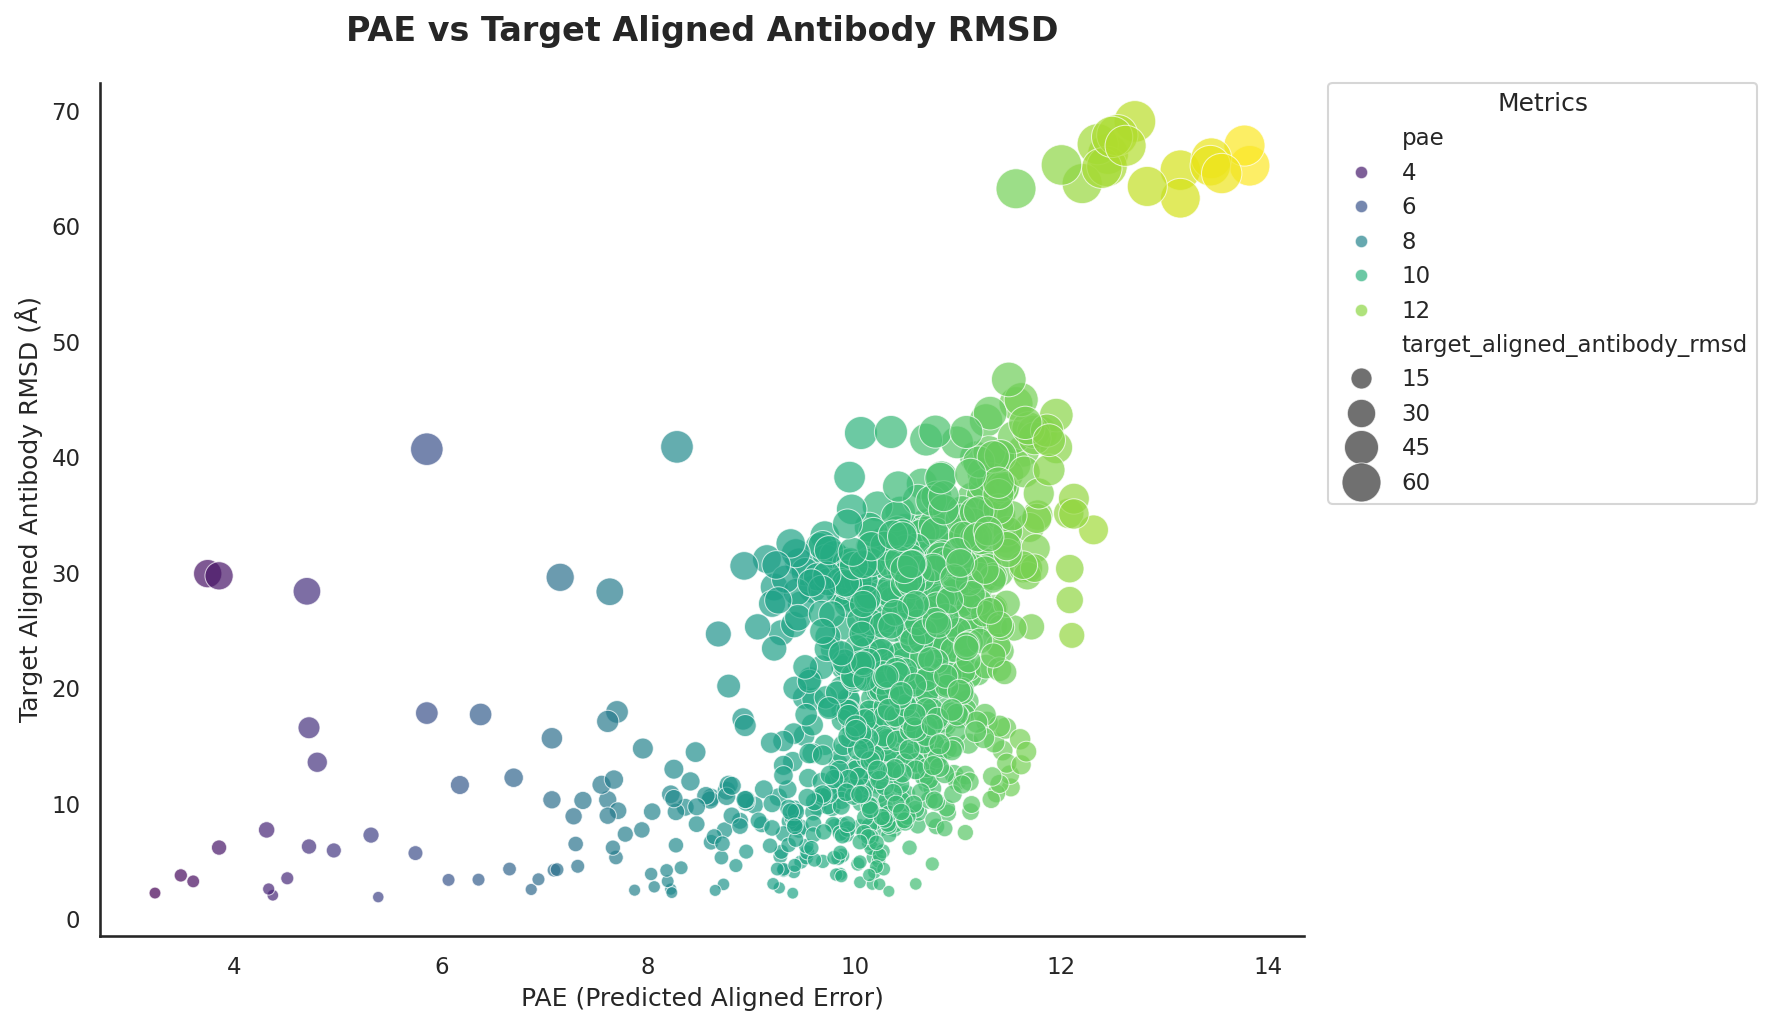

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Veriyi Yükleme
input_file = '/content/3_rf2.sc'

try:
    df = pd.read_csv(input_file, sep=r'\s+')
except FileNotFoundError:
    print("Hata: Dosya bulunamadı.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Grafik Stili Ayarları - GRID KAPALI
    # 'white' teması grid çizgilerini içermez, sade beyaz arka plan sağlar.
    sns.set_theme(style="white")

    plt.figure(figsize=(12, 7), dpi=150)

    # 3. Scatter Plot (Bubble Chart) Oluşturma
    scatter = sns.scatterplot(
        data=df,
        x='pae',
        y='target_aligned_antibody_rmsd',
        hue='pae',
        palette='viridis',
        size='target_aligned_antibody_rmsd',
        sizes=(30, 400),
        alpha=0.7,
        edgecolor='white',
        linewidth=0.5
    )

    # 4. Eksen ve Başlık Ayarları
    plt.title('PAE vs Target Aligned Antibody RMSD', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('PAE (Predicted Aligned Error)', fontsize=12)
    plt.ylabel('Target Aligned Antibody RMSD (Å)', fontsize=12)

    # Ekstra Güvenlik: Grid'i manuel olarak da kapatalım
    plt.grid(False)

    # Çerçeveyi daha zarif hale getirmek için 'despine' (üst ve sağ çizgileri kaldır)
    sns.despine()

    # 5. Lejant (Legend) Ayarı
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Metrics')

    # 6. Göster
    plt.tight_layout()
    plt.show()

else:
    print("Veri seti boş.")

### HTML interactive visualization

In [ ]:
import pandas as pd
import plotly.express as px

# 1. Loading Data
input_file = '/content/3_rf2.sc'

try:
    df = pd.read_csv(input_file, sep=r'\s+')
except FileNotFoundError:
    print("Error: File not found.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Creating Interactive Plot with Plotly
    fig = px.scatter(
        df,
        x='pae',
        y='target_aligned_antibody_rmsd',
        color='pae',  # Color scale based on PAE
        size='target_aligned_antibody_rmsd', # Size based on RMSD

        # --- INTERACTIVITY ---
        # Extra data to show on hover
        hover_data={
            'tag': True,
            'pae': ':.2f',
            'target_aligned_antibody_rmsd': ':.2f',
            'pred_lddt': True
        },

        title='Interactive PAE vs Target Aligned Antibody RMSD',
        color_continuous_scale='Viridis',
        template='plotly_white'
    )

    # 3. Visual Fine-Tuning
    fig.update_layout(
        xaxis_title="PAE (Predicted Aligned Error)",
        yaxis_title="Target Aligned Antibody RMSD (Å)",
        width=1100,
        height=700,
        font=dict(family="Arial", size=14),
    )

    # Removing grid lines
    fig.update_xaxes(showgrid=False, showline=True, linecolor='black')
    fig.update_yaxes(showgrid=False, showline=True, linecolor='black')

    # 4. Show plot
    fig.show()

else:
    print("Dataset is empty.")

Visualization saved as 'binding_accuracy_plot.png' and 'binding_accuracy_plot.pdf' (300 DPI).


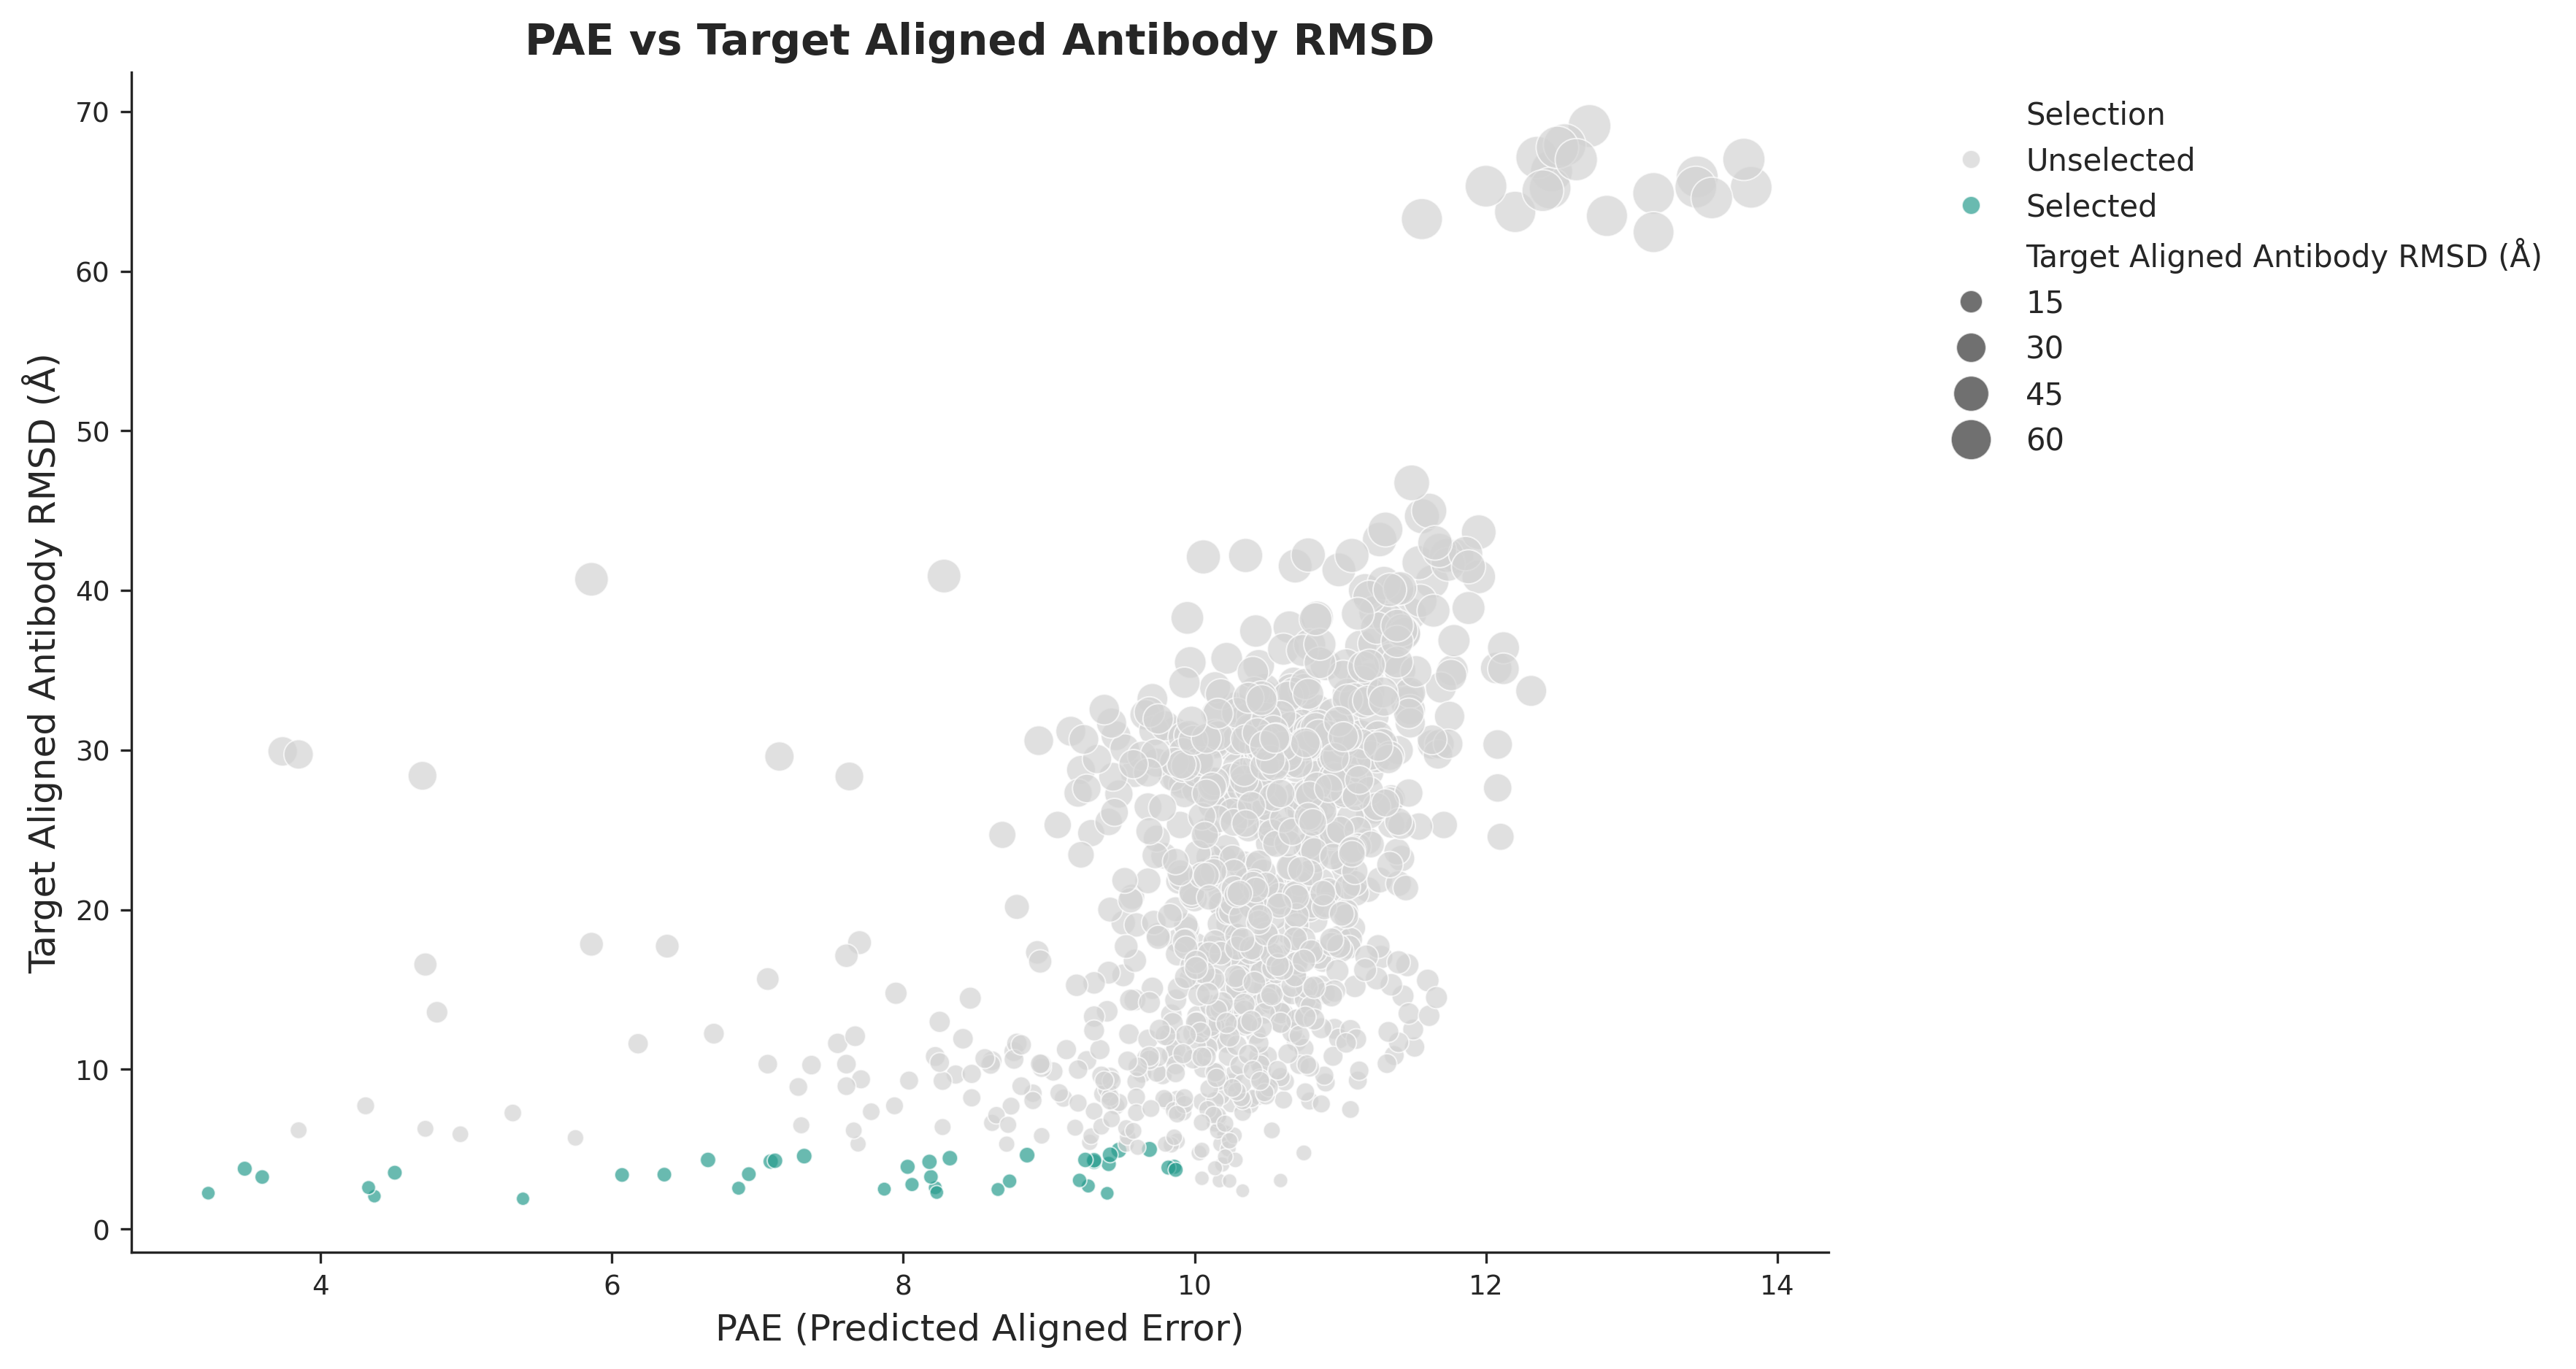

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
input_file = '/content/3_rf2.sc'

try:
    df = pd.read_csv(input_file, sep=r'\s+')
except FileNotFoundError:
    print("Error: File not found.")
    df = pd.DataFrame()

if not df.empty:
    # 2. Filtering and Renaming for Legend
    mask = (df['pae'] < 10) & (df['target_aligned_antibody_rmsd'] < 5)
    df['Selection'] = ['Selected' if m else 'Unselected' for m in mask]

    # Rename column specifically for the legend label
    df = df.rename(columns={'target_aligned_antibody_rmsd': 'Target Aligned Antibody RMSD (Å)'})

    # 3. Plotting Setup
    plt.figure(figsize=(10, 7), dpi=300)
    sns.set_style("ticks")

    # 4. Create Scatter Plot
    plot = sns.scatterplot(
        data=df,
        x='pae',
        y='Target Aligned Antibody RMSD (Å)',
        hue='Selection',
        palette={'Selected': '#2A9D8F', 'Unselected': 'lightgrey'},
        size='Target Aligned Antibody RMSD (Å)',
        sizes=(20, 200),
        alpha=0.7,
        edgecolor='white'
    )

    # 5. Labels and Title
    plt.title('PAE vs Target Aligned Antibody RMSD', fontsize=14, fontweight='bold')
    plt.xlabel('PAE (Predicted Aligned Error)', fontsize=12)
    plt.ylabel('Target Aligned Antibody RMSD (Å)', fontsize=12)

    # 6. Aesthetic Adjustments
    sns.despine()

    # Remove titles from legend by passing title=None and adjusting handles/labels if necessary
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=None, frameon=False)
    plt.grid(False)

    # 7. Save as PNG and PDF at 300 DPI
    plt.savefig('binding_accuracy_plot.png', dpi=300, bbox_inches='tight')
    plt.savefig('binding_accuracy_plot.pdf', bbox_inches='tight')

    print("Visualization saved as 'binding_accuracy_plot.png' and 'binding_accuracy_plot.pdf' (300 DPI).")
    plt.show()

else:
    print("Dataset is empty.")

## Final Filter (1000 --> 39)
`PAE < 10` and `target_aligned_antibody_rmsd < 5`

In [ ]:
import pandas as pd

# Dosya yolları
input_file = '/content/3_rf2.sc'
output_file = '/content/top_100_filtered_sorted.csv' # Çıktı ismini güncelledim

# Dosyayı yükle
df = pd.read_csv(input_file, sep=r'\s+')

# 1. Filtreleri Uygula
# pae < 10 VE target_aligned_antibody_rmsd < 8.0
filtered_df = df[
    (df['pae'] < 10) &
    (df['target_aligned_antibody_rmsd'] < 5)
].copy()

# 2. Değerlere Göre Sırala
# Öncelik PAE, sonra RMSD. (Küçükten büyüğe)
sorted_df = filtered_df.sort_values(
    by=['pae', 'target_aligned_antibody_rmsd'],
    ascending=[True, True]
)

# 3. İLK 100 TANESİNİ SEÇ
# Eğer filtre sonrası 100'den az veri kaldıysa hepsini, çoksa ilk 100'ü alır.
top_100_df = sorted_df.head(100)

# Sonuçları Göster
print(f"Filtreden Geçen Toplam Sayı: {len(sorted_df)}")
print(f"Seçilen (İlk 100) Sayısı: {len(top_100_df)}")
print("-" * 50)
print(top_100_df[['tag', 'pae', 'target_aligned_antibody_rmsd']])

# CSV olarak kaydet
top_100_df.to_csv(output_file, index=False)
print(f"Dosya kaydedildi: {output_file}")

Filtreden Geçen Toplam Sayı: 39
Seçilen (İlk 100) Sayısı: 39
--------------------------------------------------
                                   tag   pae  target_aligned_antibody_rmsd
776  samples_design_77_dldesign_6_best  3.23                          2.25
832  samples_design_83_dldesign_2_best  3.48                          3.78
771  samples_design_77_dldesign_1_best  3.60                          3.26
831  samples_design_83_dldesign_1_best  4.33                          2.60
254  samples_design_25_dldesign_4_best  4.37                          2.06
735  samples_design_73_dldesign_5_best  4.51                          3.53
252  samples_design_25_dldesign_2_best  5.39                          1.90
730  samples_design_73_dldesign_0_best  6.07                          3.39
739  samples_design_73_dldesign_9_best  6.36                          3.41
860  samples_design_86_dldesign_0_best  6.66                          4.33
482  samples_design_48_dldesign_2_best  6.87                   

In [ ]:
import pandas as pd

# Filtrelenmiş DataFrame üzerinden ortalamaları hesaplayalım
# (Bir önceki hücrede top_100_df değişkenini oluşturmuştuk)

if 'top_100_df' in locals() and not top_100_df.empty:
    pae_mean = top_100_df['pae'].mean()
    rmsd_mean = top_100_df['target_aligned_antibody_rmsd'].mean()

    print(f"Filtrelenmiş {len(top_100_df)} tasarımın ortalamaları:")
    print(f"Ortalama PAE: {pae_mean:.2f}")
    print(f"Ortalama RMSD: {rmsd_mean:.2f}")
else:
    print("Hata: top_100_df bulunamadı veya boş.")

Filtrelenmiş 39 tasarımın ortalamaları:
Ortalama PAE: 7.64
Ortalama RMSD: 3.50
